# SentinelIQ — 01 Data Exploration
Explore all three simulated data streams: logs, metrics, and network flows.

In [1]:
!git clone https://github.com/hasan-rajab/SentinelIQ.git
import sys
sys.path.append('/kaggle/working/SentinelIQ')

Cloning into 'SentinelIQ'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 49 (delta 9), reused 33 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 121.42 KiB | 13.49 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
# Generate datasets
!python /kaggle/working/SentinelIQ/data/simulated/pipeline.py --duration 120 --anomaly-rate 0.08



  SentinelIQ — Generating Training Data
  Duration: 120s | Anomaly rate: 8%

[network_simulator] Generated 2389 records.
[NETWORK] ✅ 2389 records | 203 anomalies (8.5%) → data/simulated/network.jsonl
[log_simulator] Generated 1198 records.
[LOGS   ] ✅ 1198 records | 107 anomalies (8.9%) → data/simulated/logs.jsonl
[metric_simulator] Generated 1205 records.
[METRICS] ✅ 1205 records | 92 anomalies (7.6%) → data/simulated/metrics.jsonl

  Dataset Summary

  NETWORK
    Total records : 2,389
    Anomalies     : 203
    Anomaly types : {'c2_beacon': 44, 'dns_tunneling': 42, 'data_exfiltration': 41, 'lateral_movement': 38, 'port_scan': 38}

  LOGS
    Total records : 1,198
    Anomalies     : 107
    Anomaly types : {'brute_force': 28, 'invalid_user': 19, 'privilege_escalation': 18, 'auth_failure': 17, 'unauthorized_access': 12, 'sqli': 6, 'web_shell': 4, 'path_traversal': 3}

  METRICS
    Total records : 1,205
    Anomalies     : 92
    Anomaly types : {'network_exfiltration': 20, 'connec

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

def load_jsonl(path):
    return pd.DataFrame([json.loads(l) for l in open(path)])

logs_df    = load_jsonl('data/simulated/logs.jsonl')
metrics_df = load_jsonl('data/simulated/metrics.jsonl')
network_df = load_jsonl('data/simulated/network.jsonl')

print(f"Logs    : {len(logs_df):,} records | {logs_df['is_anomaly'].sum()} anomalies")
print(f"Metrics : {len(metrics_df):,} records | {metrics_df['is_anomaly'].sum()} anomalies")
print(f"Network : {len(network_df):,} records | {network_df['is_anomaly'].sum()} anomalies")


Logs    : 1,198 records | 107 anomalies
Metrics : 1,205 records | 92 anomalies
Network : 2,389 records | 203 anomalies


## Logs Dataset

In [4]:
logs_df.head(5)


,timestamp,log_type,message,is_anomaly,anomaly_type,source
0,2026-06-16T12:30:17.861530,syslog,sshd[9238]: Accepted publickey for svc_monitor...,False,None,host-3.sentineliq.internal
1,2026-06-16T12:30:17.961744,syslog,sudo: carol : TTY=pts/0 ; PWD=/home/carol ; US...,False,None,host-5.sentineliq.internal
2,2026-06-16T12:30:18.062027,apache,192.168.1.25 - - [16/Jun/2026:12:30:18 +0000] ...,False,None,host-1.sentineliq.internal
3,2026-06-16T12:30:18.162279,syslog,"ntpd[2611]: synchronized to 192.168.1.29, stra...",False,None,host-4.sentineliq.internal
4,2026-06-16T12:30:18.262572,apache,192.168.1.39 - - [16/Jun/2026:12:30:18 +0000] ...,False,None,host-2.sentineliq.internal


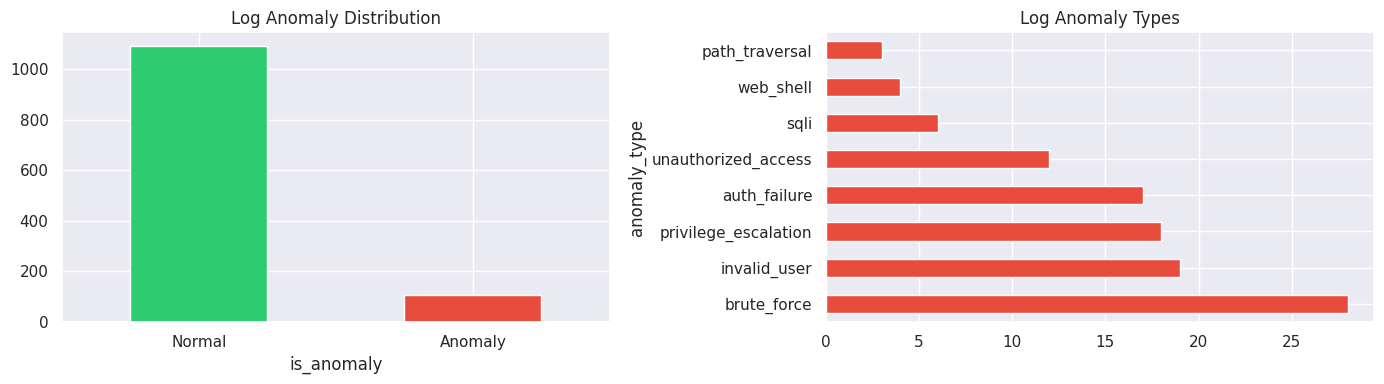

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Anomaly distribution
logs_df['is_anomaly'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Log Anomaly Distribution')
axes[0].set_xticklabels(['Normal', 'Anomaly'], rotation=0)

# Anomaly types
anomaly_types = logs_df[logs_df['is_anomaly']]['anomaly_type'].value_counts()
anomaly_types.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Log Anomaly Types')

plt.tight_layout()
plt.show()


In [6]:
# Log type breakdown
print("Log type distribution:")
print(logs_df['log_type'].value_counts())
print()
print("Sample anomalous log messages:")
for _, row in logs_df[logs_df['is_anomaly']].head(5).iterrows():
    print(f"  [{row['anomaly_type']:25}] {row['message'][:80]}")


Log type distribution:
log_type
auth      411
syslog    398
apache    389
Name: count, dtype: int64

Sample anomalous log messages:
  [auth_failure             ] sudo: pam_unix(sudo:auth): authentication failure; logname=svc_monitor uid=1000 
  [brute_force              ] sshd[4974]: Failed password for root from 45.205.101.156 port 31758 ssh2
  [invalid_user             ] sshd[2028]: Invalid user admin from 45.68.105.94 port 2845
  [invalid_user             ] sshd[2559]: Invalid user oracle from 45.178.83.80 port 32062
  [brute_force              ] sshd[3771]: Failed password for root from 45.162.41.55 port 63654 ssh2


## Metrics Dataset

In [7]:
metrics_df.head(5)


,timestamp,host,tick,cpu_percent,mem_percent,disk_read_mbps,disk_write_mbps,net_in_mbps,net_out_mbps,open_connections,process_count,is_anomaly,anomaly_type
0,2026-06-16T12:30:17.863397,host-1,0,22.97,56.89,4.658,3.115,9.101,6.400,53,129,False,None
1,2026-06-16T12:30:17.863462,host-2,0,41.87,73.61,8.832,5.720,20.534,10.550,52,125,False,None
2,2026-06-16T12:30:17.863490,host-3,0,19.61,47.59,2.530,1.293,5.925,1.927,59,116,False,None
3,2026-06-16T12:30:17.863511,host-4,0,59.61,81.52,14.691,9.465,28.658,17.888,40,135,False,None
4,2026-06-16T12:30:17.863533,host-5,0,29.48,53.80,6.917,4.383,18.260,9.974,45,119,False,None


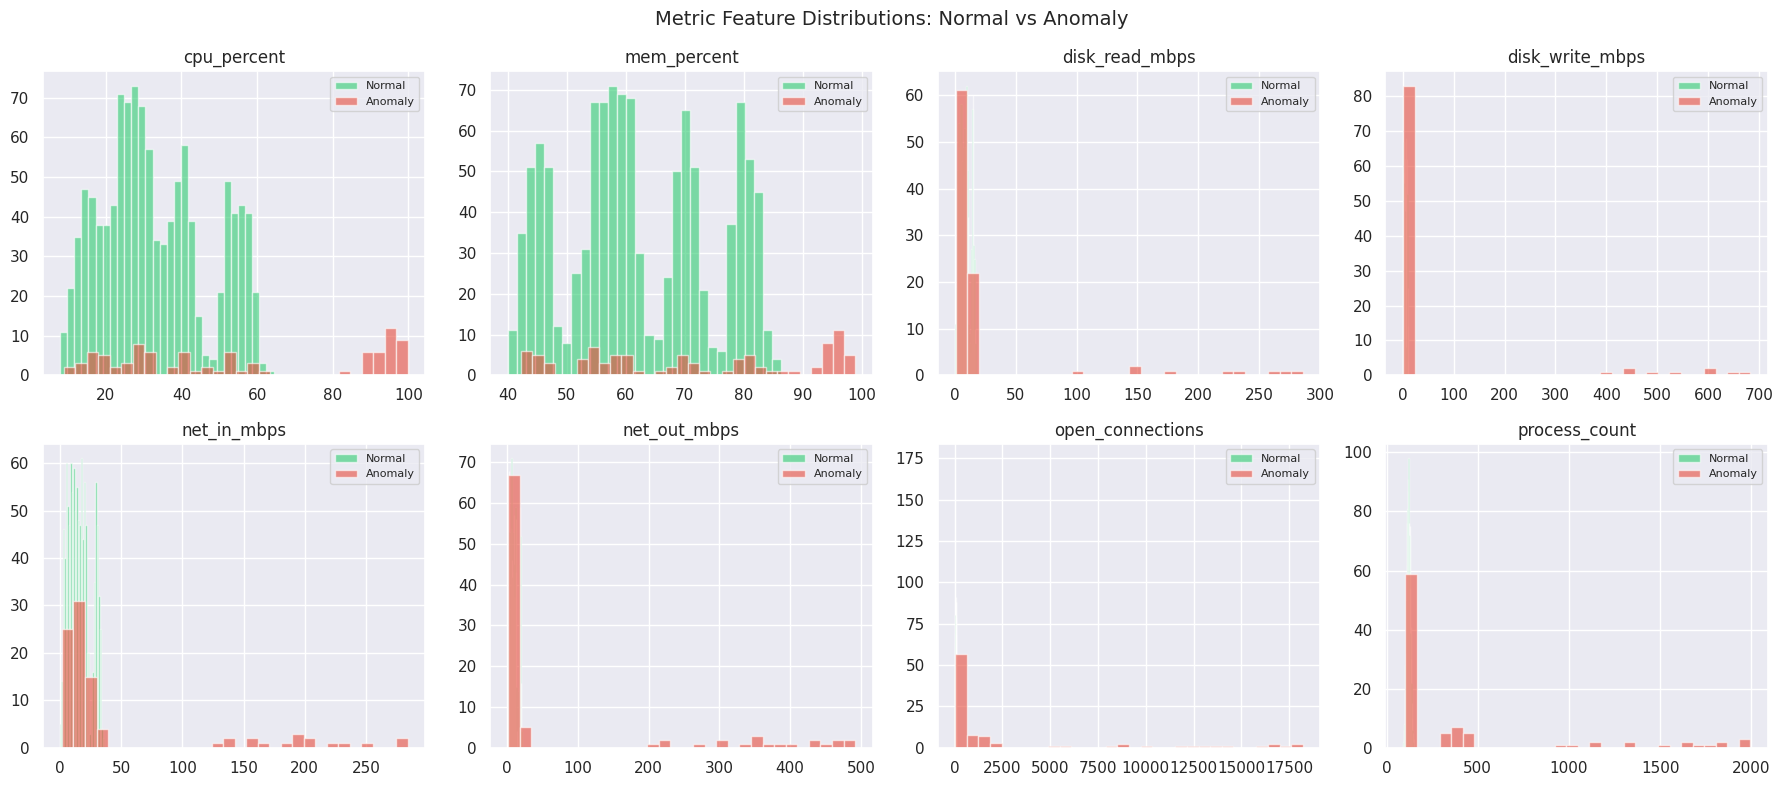

In [8]:
feature_cols = ['cpu_percent','mem_percent','disk_read_mbps',
                'disk_write_mbps','net_in_mbps','net_out_mbps',
                'open_connections','process_count']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    normal = metrics_df[~metrics_df['is_anomaly']][col]
    anomaly = metrics_df[metrics_df['is_anomaly']][col]
    axes[i].hist(normal, bins=30, alpha=0.6, color='#2ecc71', label='Normal')
    axes[i].hist(anomaly, bins=30, alpha=0.6, color='#e74c3c', label='Anomaly')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Metric Feature Distributions: Normal vs Anomaly', fontsize=14)
plt.tight_layout()
plt.show()


In [9]:
print("Metrics anomaly types:")
print(metrics_df[metrics_df['is_anomaly']]['anomaly_type'].value_counts())
print()
print("Feature statistics (normal vs anomaly):")
print(metrics_df.groupby('is_anomaly')[feature_cols].mean().T.rename(columns={False:'Normal Mean', True:'Anomaly Mean'}))


Metrics anomaly types:
anomaly_type
network_exfiltration    20
connection_storm        17
cpu_spike               17
process_bomb            16
memory_leak             13
disk_flood               9
Name: count, dtype: int64

Feature statistics (normal vs anomaly):
is_anomaly        Normal Mean  Anomaly Mean
cpu_percent         32.990234     55.642739
mem_percent         62.161186     71.684239
disk_read_mbps       8.044774     27.356576
disk_write_mbps      4.814038     57.235598
net_in_mbps         16.003681     48.781391
net_out_mbps         9.613341     87.248543
open_connections    49.630728   2627.532609
process_count      119.523810    417.695652


## Network Dataset

In [10]:
network_df.head(5)


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_out,bytes_in,packets,duration_ms,service,is_anomaly,anomaly_type
0,2026-06-16T12:30:17.863975,10.0.0.7,8.8.8.8,49580,53,UDP,53,255,4,10,DNS,False,None
1,2026-06-16T12:30:17.914239,10.0.0.4,10.0.0.17,58971,587,TCP,9768,7738,16,447,SUBMISSION,False,None
2,2026-06-16T12:30:17.964498,10.0.0.19,10.0.0.2,63492,443,TCP,5930,6545,10,214,HTTPS,False,None
3,2026-06-16T12:30:18.014708,10.0.0.3,13.32.99.87,51888,80,TCP,4101,31946,49,1874,HTTP,False,None
4,2026-06-16T12:30:18.064872,10.0.0.4,142.250.80.46,53402,443,TCP,1304,26259,20,1833,HTTPS,False,None


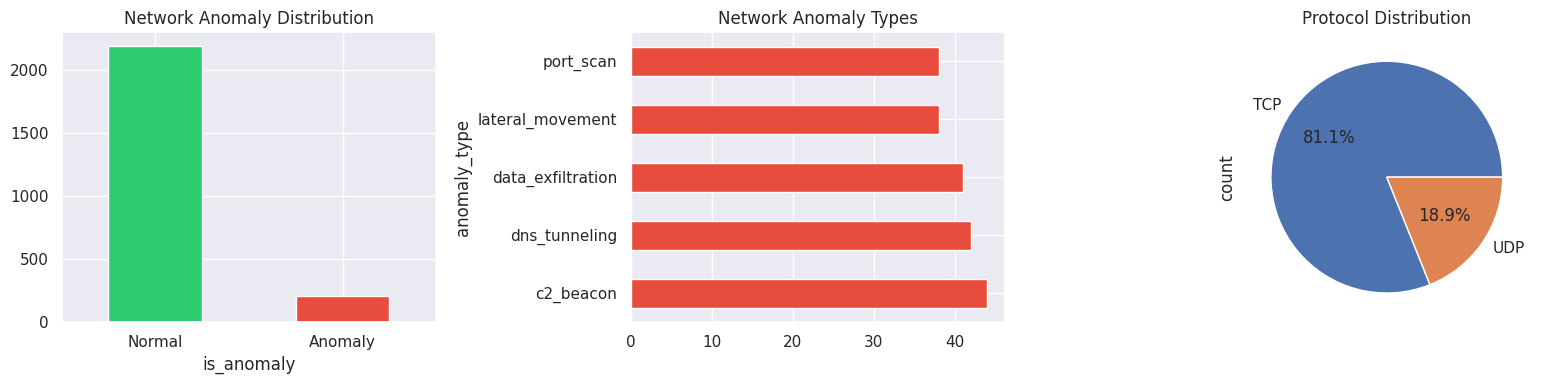

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Anomaly distribution
network_df['is_anomaly'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Network Anomaly Distribution')
axes[0].set_xticklabels(['Normal','Anomaly'], rotation=0)

# Anomaly types
network_df[network_df['is_anomaly']]['anomaly_type'].value_counts().plot(
    kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Network Anomaly Types')

# Protocol distribution
network_df['protocol'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%')
axes[2].set_title('Protocol Distribution')

plt.tight_layout()
plt.show()


In [12]:
net_features = ['bytes_out','bytes_in','packets','duration_ms']
print("Network feature stats (normal vs anomaly):")
print(network_df.groupby('is_anomaly')[net_features].mean().T.rename(
    columns={False:'Normal Mean', True:'Anomaly Mean'}))

print()
print("Top destination ports:")
print(network_df['dst_port'].value_counts().head(10))


Network feature stats (normal vs anomaly):
is_anomaly    Normal Mean  Anomaly Mean
bytes_out     2766.968893  5.710788e+07
bytes_in     16239.781336  2.285562e+03
packets         20.435499  5.079302e+04
duration_ms    696.400274  3.548105e+04

Top destination ports:
dst_port
443     722
80      712
53      499
22       70
25       52
8080     48
5432     46
6379     43
587      41
3306     41
Name: count, dtype: int64


## Correlation Analysis (Metrics)

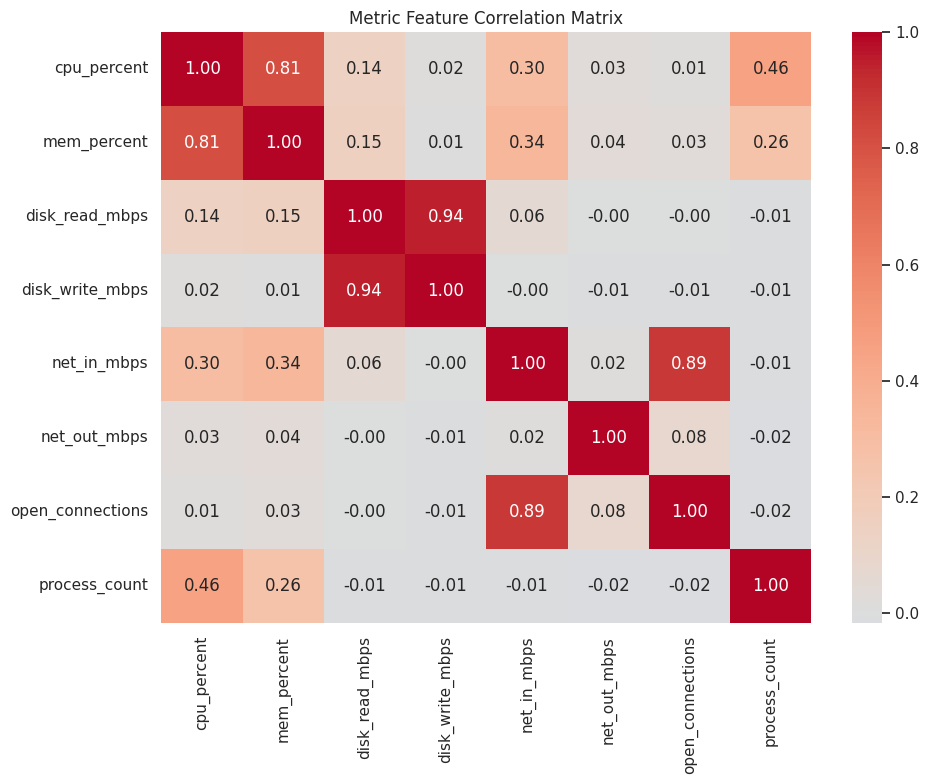

In [13]:
corr = metrics_df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Metric Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## Summary
- All three data streams are generating correctly
- Anomaly rates are ~8% as configured
- Feature distributions show clear separation between normal and anomaly classes
- Ready for Phase 2 model training